In [6]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER

Mounted at /content/drive
fatal: destination path '/content/TER' already exists and is not an empty directory.


In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Done ✓


In [ ]:
import pandas as pd

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['Tweet', 'sentiment', 'Date'],
                 low_memory=False)

df = df.dropna(subset=['Tweet', 'sentiment'])
df = df[df['Tweet'].str.strip() != '']

label2id = {'positive': 0, 'neutral': 1, 'negative': 2}
id2label = {0: 'positive', 1: 'neutral', 2: 'negative'}
df['label'] = df['sentiment'].map(label2id)

print(f"Shape: {df.shape}")
print(df['sentiment'].value_counts())

Shape: (476193, 4)
sentiment
positive    249982
neutral     150924
negative     75287
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Échantillon stratifié 50k
df_sample = df.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(frac=50000/len(df), random_state=42)
).reset_index(drop=True)

print(f"Sample size: {len(df_sample)}")
print(df_sample['sentiment'].value_counts())

# Split temporel : 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df_sample, test_size=0.30, random_state=42, stratify=df_sample['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Sample size: 50000
sentiment
positive    26248
neutral     15847
negative     7905
Name: count, dtype: int64

Train: 35000 | Val: 7500 | Test: 7500


/tmp/ipykernel_2951/141824493.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('sentiment', group_keys=False).apply(


In [ ]:
from transformers import AutoTokenizer
import torch

# Charger le tokenizer BERTweet
tokenizer = AutoTokenizer.from_pretrained('vinai/bertweet-base', use_fast=False)

# Vérifier le GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Test tokenization
sample = train_df['Tweet'].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=128, padding='max_length', return_tensors='pt')
print(f"\nSample tweet: {sample[:80]}...")
print(f"Token ids shape: {tokens['input_ids'].shape}")

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Device: cuda

Sample tweet: #chatgpt is seriously impressive, but i think there are still big leaps to go in...
Token ids shape: torch.Size([1, 128])


In [ ]:
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

print("Tokenizing train set...")
train_dataset = TweetDataset(train_df['Tweet'], train_df['label'], tokenizer)
print("Tokenizing val set...")
val_dataset = TweetDataset(val_df['Tweet'], val_df['label'], tokenizer)
print("Tokenizing test set...")
test_dataset = TweetDataset(test_df['Tweet'], test_df['label'], tokenizer)

print(f"\nDone ✓")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Tokenizing train set...
Tokenizing val set...
Tokenizing test set...

Done ✓
Train: 35000 | Val: 7500 | Test: 7500


In [ ]:
from transformers import AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
import numpy as np

# Charger BERTweet
print("Loading BERTweet model...")
model = AutoModelForSequenceClassification.from_pretrained(
    'vinai/bertweet-base',
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)
print("Model loaded ✓")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Optimizer + Scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 3
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"\nTraining config:")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: 32")
print(f"  Total steps: {total_steps}")
print(f"  Learning rate: 2e-5")

Loading BERTweet model...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✓

Training config:
  Epochs: 3
  Batch size: 32
  Total steps: 3282
  Learning rate: 2e-5


In [ ]:
import time
import os

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return f1

# Create directory for saving models if it doesn't exist
os.makedirs('/content/TER/outputs', exist_ok=True)

# Training loop
best_f1 = 0
history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if step % 100 == 0:
            print(f"  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    val_f1 = evaluate(model, val_loader, device)
    elapsed = time.time() - t0

    history.append({'epoch': epoch+1, 'loss': avg_loss, 'val_f1': val_f1})
    print(f"\nEpoch {epoch+1}/{num_epochs} — Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} | Time: {elapsed:.0f}s")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), '/content/TER/outputs/bertweet_best.pt')
        print(f"  ✓ Best model saved (F1={best_f1:.4f})")

print(f"\nTraining complete! Best Val F1: {best_f1:.4f}")

  Epoch 1 | Step 0/1094 | Loss: 0.1695
  Epoch 1 | Step 100/1094 | Loss: 0.2860
  Epoch 1 | Step 200/1094 | Loss: 0.2196
  Epoch 1 | Step 300/1094 | Loss: 0.5479
  Epoch 1 | Step 400/1094 | Loss: 0.2860
  Epoch 1 | Step 500/1094 | Loss: 0.2908
  Epoch 1 | Step 600/1094 | Loss: 0.3411
  Epoch 1 | Step 700/1094 | Loss: 0.1504
  Epoch 1 | Step 800/1094 | Loss: 0.2517
  Epoch 1 | Step 900/1094 | Loss: 0.1529
  Epoch 1 | Step 1000/1094 | Loss: 0.1346

Epoch 1/3 — Loss: 0.2788 | Val F1: 0.8902 | Time: 839s
  ✓ Best model saved (F1=0.8902)
  Epoch 2 | Step 0/1094 | Loss: 0.0761
  Epoch 2 | Step 100/1094 | Loss: 0.2937
  Epoch 2 | Step 200/1094 | Loss: 0.1996
  Epoch 2 | Step 300/1094 | Loss: 0.0664
  Epoch 2 | Step 400/1094 | Loss: 0.1615
  Epoch 2 | Step 500/1094 | Loss: 0.1381
  Epoch 2 | Step 600/1094 | Loss: 0.0224
  Epoch 2 | Step 700/1094 | Loss: 0.1058
  Epoch 2 | Step 800/1094 | Loss: 0.1987
  Epoch 2 | Step 900/1094 | Loss: 0.2110
  Epoch 2 | Step 1000/1094 | Loss: 0.0988

Epoch 2/3 

=== Test Set Results ===
              precision    recall  f1-score   support

    positive       0.93      0.95      0.94      3937
     neutral       0.95      0.89      0.92      2377
    negative       0.81      0.86      0.83      1186

    accuracy                           0.91      7500
   macro avg       0.89      0.90      0.90      7500
weighted avg       0.92      0.91      0.92      7500



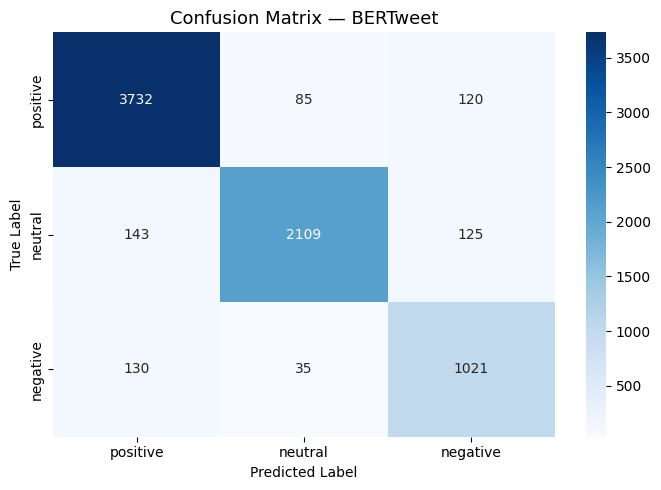

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le meilleur modèle
model.load_state_dict(torch.load('/content/TER/outputs/bertweet_best.pt'))
model.eval()

# Évaluation sur test set
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Métriques
label_names = ['positive', 'neutral', 'negative']
print("=== Test Set Results ===")
print(classification_report(all_labels, all_preds, target_names=label_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — BERTweet', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/TER/figures/09_bertweet_confusion_matrix.png', dpi=150)
plt.show()

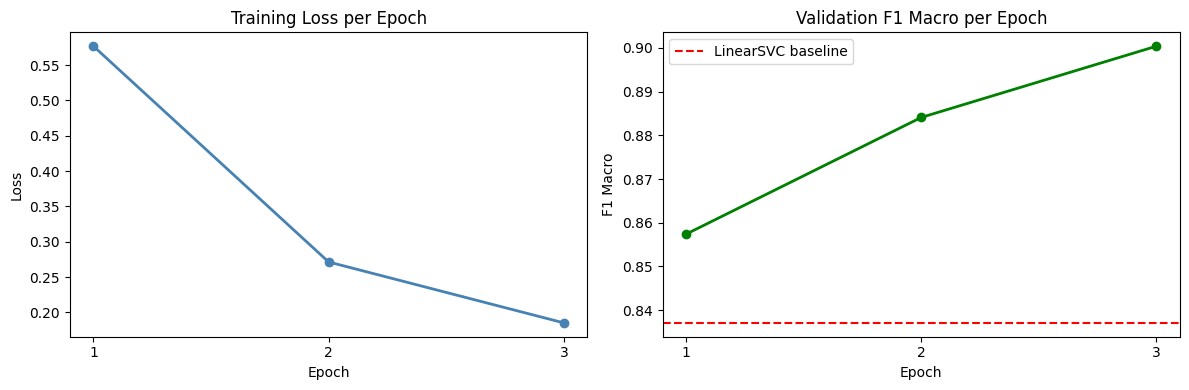

In [4]:
import matplotlib.pyplot as plt

# Résultats qu'on a déjà obtenus
history = [
    {'epoch': 1, 'loss': 0.5767, 'val_f1': 0.8574},
    {'epoch': 2, 'loss': 0.2713, 'val_f1': 0.8841},
    {'epoch': 3, 'loss': 0.1851, 'val_f1': 0.9004},
]

epochs = [h['epoch'] for h in history]
losses = [h['loss'] for h in history]
f1s = [h['val_f1'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, losses, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)

axes[1].plot(epochs, f1s, 'o-', color='green', linewidth=2)
axes[1].axhline(0.8371, color='red', linestyle='--', linewidth=1.5, label='LinearSVC baseline')
axes[1].set_title('Validation F1 Macro per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Macro')
axes[1].set_xticks(epochs)
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/TER/figures/10_bertweet_training_curve.png', dpi=150)
plt.show()

In [3]:
import os
os.makedirs('/content/TER/figures', exist_ok=True)
plt.savefig('/content/TER/figures/10_bertweet_training_curve.png', dpi=150)
print("Saved ✓")

Saved ✓


<Figure size 640x480 with 0 Axes>

In [8]:
import os, shutil, subprocess
from getpass import getpass

# Créer les dossiers manquants
os.makedirs('/content/TER/notebooks', exist_ok=True)
os.makedirs('/content/TER/figures', exist_ok=True)
os.makedirs('/content/TER/outputs', exist_ok=True)

# Copier le notebook
shutil.copy('/content/drive/MyDrive/Colab Notebooks/06_bertweet_finetuning.ipynb',
            '/content/TER/notebooks/06_bertweet_finetuning.ipynb')

subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
subprocess.run(['git', 'commit', '-m', 'Add BERTweet fine-tuning notebook + results (F1=0.90)'], cwd='/content/TER')

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

Token : ··········
 fatal: not a git repository (or any of the parent directories): .git



In [9]:
import os
print(os.path.exists('/content/TER'))
print(os.path.exists('/content/TER/.git'))

True
False
